# Run adaptive immune system with noisy pMHCs

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d

import multiprocessing as mp
from tqdm import tqdm
from joblib import Parallel, delayed
import os
from sklearn.feature_selection import mutual_info_classif
from stoch_sim_model import *

plt.style.use('/Users/ObinnaUkogu/Desktop/custom.mplstyle')
%config InlineBackend.figure_format = 'retina'

### (1) Plot sample trajectory

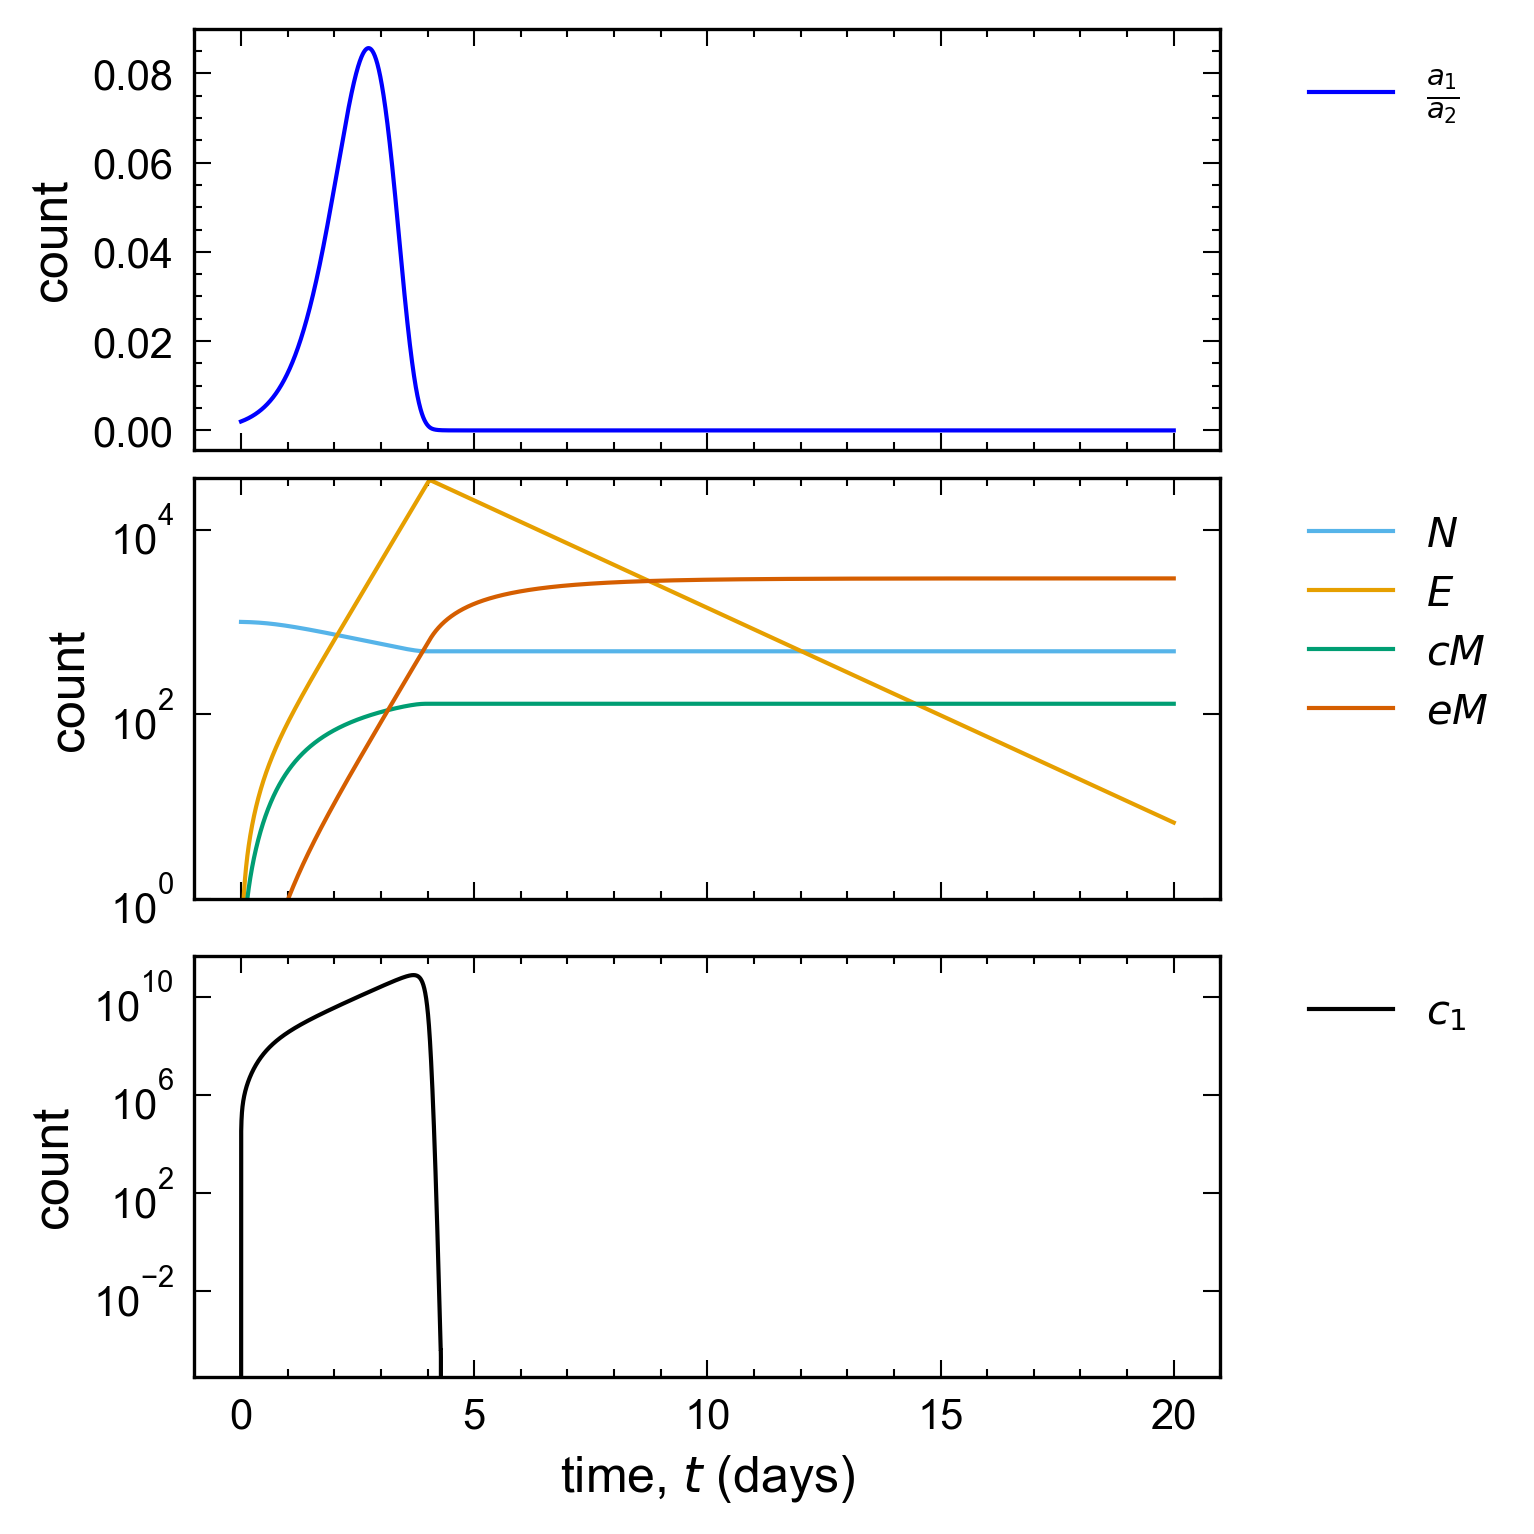

In [2]:
# Plot outputs
b_a1 = 2
t1 = 10
d_a1 = 3.8*10**(-4)
T_a1 = 10
duration = 20
steps = 10**4

a1, N, E, cM, eM, T, ts = stoch_sim(b_a1 = b_a1, t1 = t1, d_a1 = d_a1, T_a1 = T_a1, duration = duration, steps = steps)

fig, (ax1, ax2, ax3) = plt.subplots(3, dpi = 150, constrained_layout=True, sharex = True, figsize=(5,5))
ax1.plot(ts, a1/a2, 'b', label = r'$\frac{a_1}{a_2}$')
#ax1.plot(ts, P1.py_func(a1, E)[0], 'k', label = r'$[p_1MHC]$')
ax1.set(ylabel='count')
ax1.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')

ax2.plot(ts, N, label = r'$N$')
ax2.plot(ts, E, label = r'$E$')
ax2.plot(ts, cM, label = r'$cM$')
ax2.plot(ts, eM, label = r'$eM$')
ax2.set(ylabel='count')
ax2.set_ylim(1,)
ax2.semilogy()
ax2.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')

ax3.plot(ts, c1_ss.py_func(t1,a1, E, T),'k-', label = r'$c_1$')
#ax3.plot(ts, c1_ss(P1.py_func(a1, E)[0], E, T)/k_E,'k-', label = r'$\frac{c_1}{k_E}$')
#ax3.plot(ts, c2_ss(a1,E),'k-.', label = r'$c_2$')
ax3.set(xlabel=r'time, $t$ (days)', ylabel='count')
ax3.semilogy()
ax3.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')

fig.savefig('virus-effector dynamics.png', dpi=150)

## (2) Parallelize simulation runs

In [3]:
# Parallelize simulation runs
def for_parallel(b_a1, t1, d_a1, T_a1):
    # compute state and costate dynamics
    dt = duration/steps
    a1, N, E, cM, eM, T, ts = stoch_sim(b_a1, t1, d_a1, T_a1, duration = duration, steps = steps)
    run_data = [b_a1, t1, d_a1, T_a1, np.sum(a1*dt), np.argmax(a1)*dt, np.max(E), \
                np.argmax(E)*dt, eM[-1]/np.max(E), np.sum(E*dt)]
    return run_data

stat_names = [r"$g_{a_1}$",r"$t_1$",r"$d_{a_1}$",r"$T_{a_1}$",r"$\int a_1 dt$",\
                             r"$T_{a_1}^{max}$", r"$E^{max}$",r"$T_{E}^{max}$",\
                             r"$\frac{M^\infty}{E^{max}}$",r"$\int E dt$"]

In [4]:
# Set global simulation parameters
runs = 10000

In [5]:
# run several simulations varying b_a1
mu_t1 = t1
mu_b_a1 = 2
mu_d_a1 = 0.0072 # proxy for virulence
mu_T_a1 = 10

#b_a1s = np.random.uniform(0, 2*mu_b_a1, size = runs) 
b_a1s = np.abs(np.random.normal(loc = mu_b_a1, scale = mu_b_a1/np.sqrt(12), size = runs))
t1s = [mu_t1]
d_a1s = [mu_d_a1]
T_a1s = [mu_T_a1]

run_data_b_a1 = np.array(Parallel(n_jobs=os.cpu_count(), batch_size=int(len(b_a1s)/8))(delayed(for_parallel)(b_a1, t1, d_a1, T_a1)
                                              for b_a1 in b_a1s
                                              for t1 in t1s
                                              for d_a1 in d_a1s
                                              for T_a1 in T_a1s))

In [6]:
# run several simulations varying t1
mu_t1 = t1
mu_b_a1 = 2
mu_d_a1 = 0.0072 # proxy for virulence
mu_T_a1 = 10

b_a1s = [mu_b_a1] #np.abs(np.random.normal(loc = mu_b_a1, scale = mu_b_a1, size = runs))

#t1s = np.random.uniform(1, 2*mu_t1, size = runs) 
t1s = np.abs(np.random.normal(loc = mu_t1, scale = mu_t1/np.sqrt(100), size = runs)) # there is a threshold for activation
d_a1s = [mu_d_a1]
T_a1s = [mu_T_a1]

run_data_t1 = np.nan_to_num(np.array(Parallel(n_jobs=os.cpu_count(), batch_size=int(len(t1s)/8))(delayed(for_parallel)(b_a1, t1, d_a1, T_a1)
                                              for b_a1 in b_a1s
                                              for t1 in t1s
                                              for d_a1 in d_a1s
                                              for T_a1 in T_a1s)))

In [7]:
# run several simulations varying d_a1
mu_t1 = t1
mu_b_a1 = 2
mu_d_a1 = 0.0072 # proxy for virulence
mu_T_a1 = 10

b_a1s = [mu_b_a1] #np.abs(np.random.normal(loc = mu_b_a1, scale = mu_b_a1, size = runs))

#t1s = np.random.uniform(1, 2*mu_t1, size = runs) 
t1s = [mu_t1]
d_a1s = np.abs(np.random.normal(loc = mu_d_a1, scale = mu_d_a1/np.sqrt(12), size = runs))
T_a1s = [mu_T_a1]

run_data_d_a1 = np.array(Parallel(n_jobs=os.cpu_count(), batch_size=int(len(d_a1s)/8))(delayed(for_parallel)(b_a1, t1, d_a1, T_a1)
                                              for b_a1 in b_a1s
                                              for t1 in t1s
                                              for d_a1 in d_a1s
                                              for T_a1 in T_a1s))

In [8]:
# run several simulations varying T_a1
mu_t1 = t1
mu_b_a1 = 2
mu_d_a1 = 0.0072 # proxy for virulence
mu_T_a1 = 10

b_a1s = [mu_b_a1]
#t1s = np.random.uniform(1, 2*mu_t1, size = runs) 
t1s = [mu_t1]
d_a1s = [mu_d_a1]
T_a1s = np.abs(np.random.normal(loc = mu_T_a1, scale = mu_T_a1/np.sqrt(12), size = runs))

run_data_T_a1 = np.array(Parallel(n_jobs=os.cpu_count(), batch_size=int(len(T_a1s)/8))(delayed(for_parallel)(b_a1, t1, d_a1, T_a1)
                                              for b_a1 in b_a1s
                                              for t1 in t1s
                                              for d_a1 in d_a1s
                                              for T_a1 in T_a1s))

## (3) Plot distribution of response statistics from simulations varying $g_{a_1}$ and $t_1$

In [9]:
# # Plot summary statistics for b_a1
# fig_b_a1, axs = plt.subplots(5, 2, dpi = 150, constrained_layout=True, figsize=(8,10))
# i = 0
# for ax, val in zip(axs.flat,stat_names):

#     cs = ax.hist(run_data_b_a1[:,i],bins = "auto")
#     ax.set_title(val)
        
#     i += 1

# fig_b_a1.suptitle(r'Features of the infection response while varying $g_{a_1}$ (Gaussian)')
# plt.show()
# fig_b_a1.savefig('response-varying-b_a1-gauss.png', dpi=150)

In [10]:
# # Plot summary statistics for t1
# fig_t1, axs = plt.subplots(4, 2, dpi = 150, constrained_layout=True, figsize=(8,10))
# i = 0
# for ax, val in zip(axs.flat,stat_names):

#     cs = ax.hist(run_data_t1[:,i],bins = "auto")
#     ax.set_title(val)
        
#     i += 1

# fig_t1.suptitle(r'Features of the infection response while varying $t_1$')
# plt.show()
# fig_t1.savefig('response-varying-t1-gauss.png', dpi=150)

## (4) Compute correlations in data

In [11]:
# # Compute correlations and make plots
# corr_b_a1 = np.corrcoef(run_data_b_a1, rowvar = False)
# corr_t1 = np.corrcoef(run_data_t1, rowvar = False)
# corr_d_a1 = np.corrcoef(run_data_d_a1, rowvar = False)
# corr_T_a1 = np.corrcoef(run_data_T_a1, rowvar = False)

# plt.figure(1)

# r = 2*np.arange(len(corr_b_a1))
# width = 0.25
# plt.bar(r, corr_b_a1[:,0], width = width, label = r'vary $g_{a_1}$')
# plt.bar(r + width, corr_t1[:,1], width = width, label = r'vary $t_1$')
# plt.bar(r + 2*width, corr_d_a1[:,2], width = width, label = r'vary $d_{a_1}$')
# plt.bar(r + 3*width, corr_T_a1[:,3], width = width, label = r'vary $T_{a_1}$')

# plt.xlabel("response")
# plt.ylabel("pearson correlation")

# plt.xticks(r + 3*width/2,stat_names)

# plt.legend()
# plt.suptitle(r'Correlations between $g_{a_1}, t_1, d_{a_1}, T_{a_1}$ (Gaussian) respectively and response features')
# plt.savefig('response-corr-gauss.png', dpi=150)

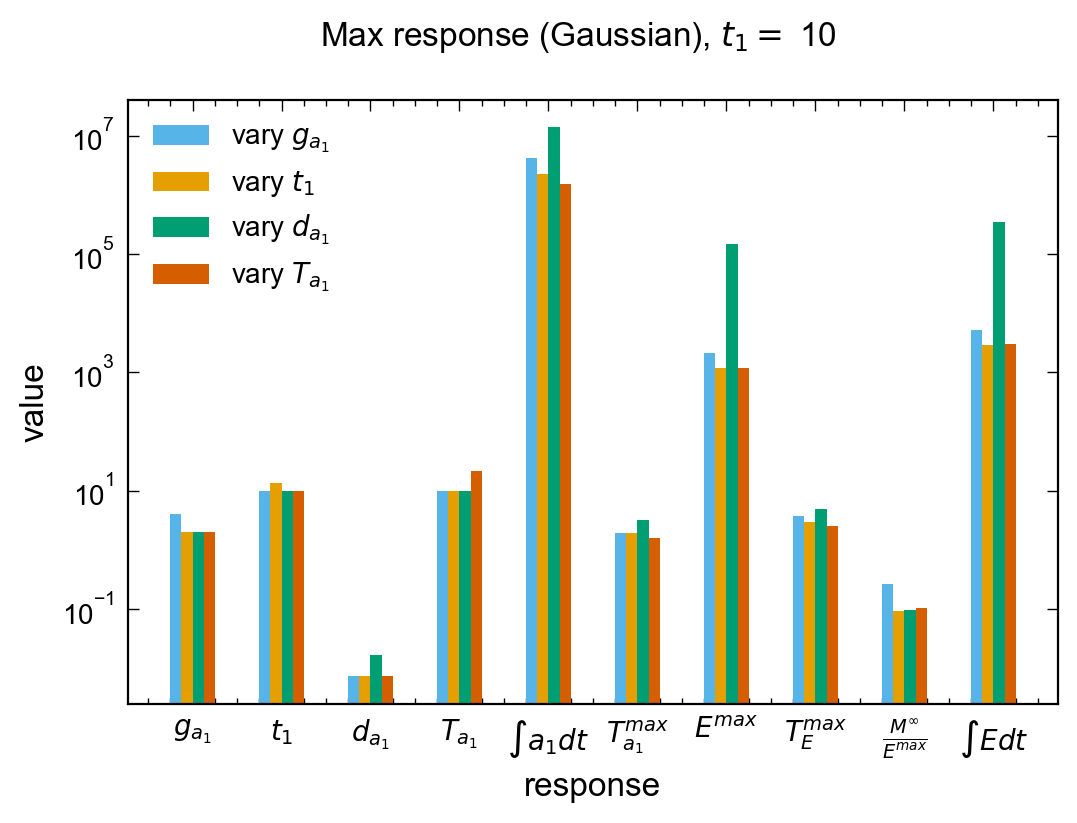

In [12]:
# Compute max values in the data
r = 2*np.arange(len(stat_names))
width = 0.25
plt.bar(r, np.amax(run_data_b_a1, axis = 0), width = width, label = r'vary $g_{a_1}$')
plt.bar(r + width, np.amax(run_data_t1, axis = 0), width = width, label = r'vary $t_1$')
plt.bar(r + 2*width, np.amax(run_data_d_a1, axis = 0), width = width, label = r'vary $d_{a_1}$')
plt.bar(r + 3*width, np.amax(run_data_T_a1, axis = 0), width = width, label = r'vary $T_{a_1}$')

plt.xlabel("response")
plt.ylabel("value")

plt.xticks(r + 3*width/2,stat_names)

plt.semilogy()
plt.legend()
plt.suptitle(r'Max response (Gaussian), $t_1=$ '+str(mu_t1))
plt.savefig('response-max-gauss-t1-'+str(mu_t1)+'.png', dpi=150)

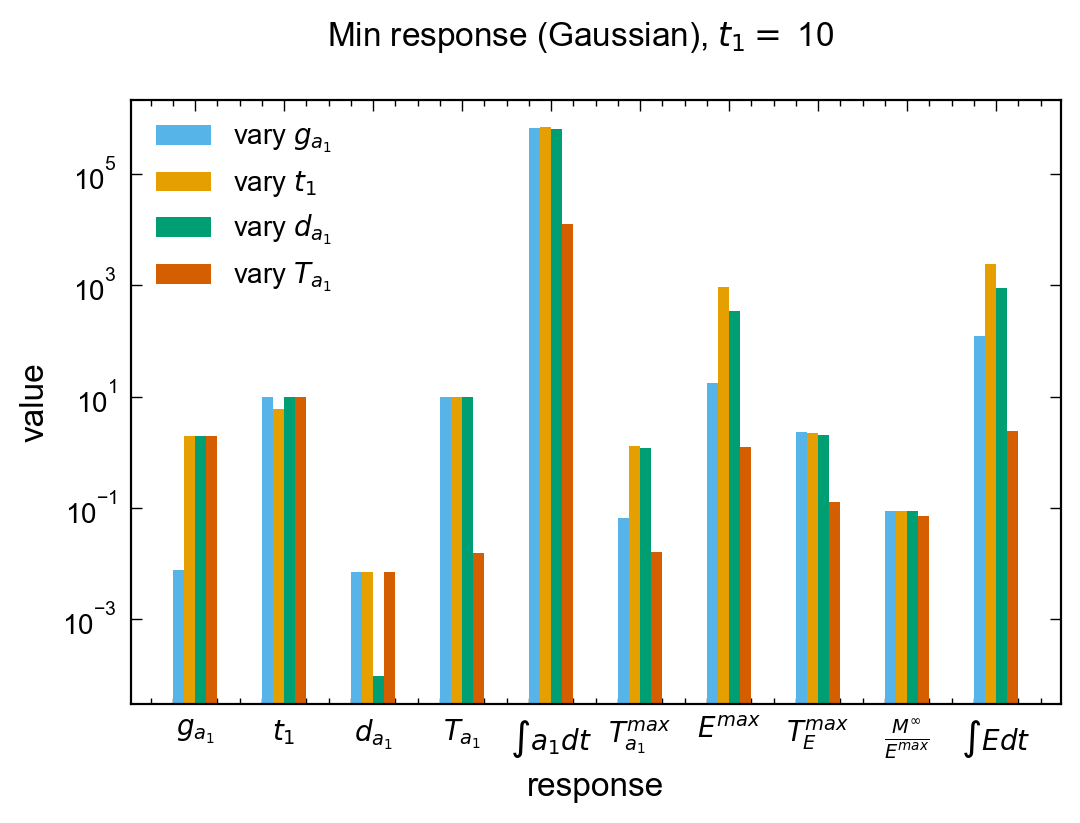

In [13]:
# Compute minimum values in the data
r = 2*np.arange(len(stat_names))
width = 0.25
plt.bar(r, np.amin(run_data_b_a1, axis = 0), width = width, label = r'vary $g_{a_1}$')
plt.bar(r + width, np.amin(run_data_t1, axis = 0), width = width, label = r'vary $t_1$')
plt.bar(r + 2*width, np.amin(run_data_d_a1, axis = 0), width = width, label = r'vary $d_{a_1}$')
plt.bar(r + 3*width, np.amin(run_data_T_a1, axis = 0), width = width, label = r'vary $T_{a_1}$')

plt.xlabel("response")
plt.ylabel("value")

plt.xticks(r + 3*width/2,stat_names)

plt.semilogy()
plt.legend()
plt.suptitle(r'Min response (Gaussian), $t_1=$ '+str(mu_t1))
plt.savefig('response-min-gauss-t1-'+str(mu_t1)+'.png', dpi=150)

## (5) Compute mutual information between variables

In [14]:
# define basic mutual information function
from sklearn.metrics import mutual_info_score

def calc_MI(x, y):
    bx = np.histogram_bin_edges(x, bins="auto", range=None, weights=None)
    by = np.histogram_bin_edges(y, bins="auto", range=None, weights=None)
    
    c_xy = np.histogram2d(x, y, [bx,by])[0]
    mi = mutual_info_score(None, None, contingency=c_xy)/np.log(2)
    return mi

In [15]:
# compute mutual information
MI_b_a1 = np.zeros(run_data_b_a1.shape[1])
for i in range(run_data_b_a1.shape[1]):
    MI_b_a1[i] = calc_MI(run_data_b_a1[:,0],run_data_b_a1[:,i])

MI_t1 = np.zeros(run_data_t1.shape[1])
for i in range(run_data_t1.shape[1]):
    MI_t1[i] = calc_MI(run_data_t1[:,1],run_data_t1[:,i])
    
MI_d_a1 = np.zeros(run_data_d_a1.shape[1])
for i in range(run_data_d_a1.shape[1]):
    MI_d_a1[i] = calc_MI(run_data_d_a1[:,2],run_data_d_a1[:,i])
    
MI_T_a1 = np.zeros(run_data_T_a1.shape[1])
for i in range(run_data_T_a1.shape[1]):
    MI_T_a1[i] = calc_MI(run_data_T_a1[:,3],run_data_T_a1[:,i])  

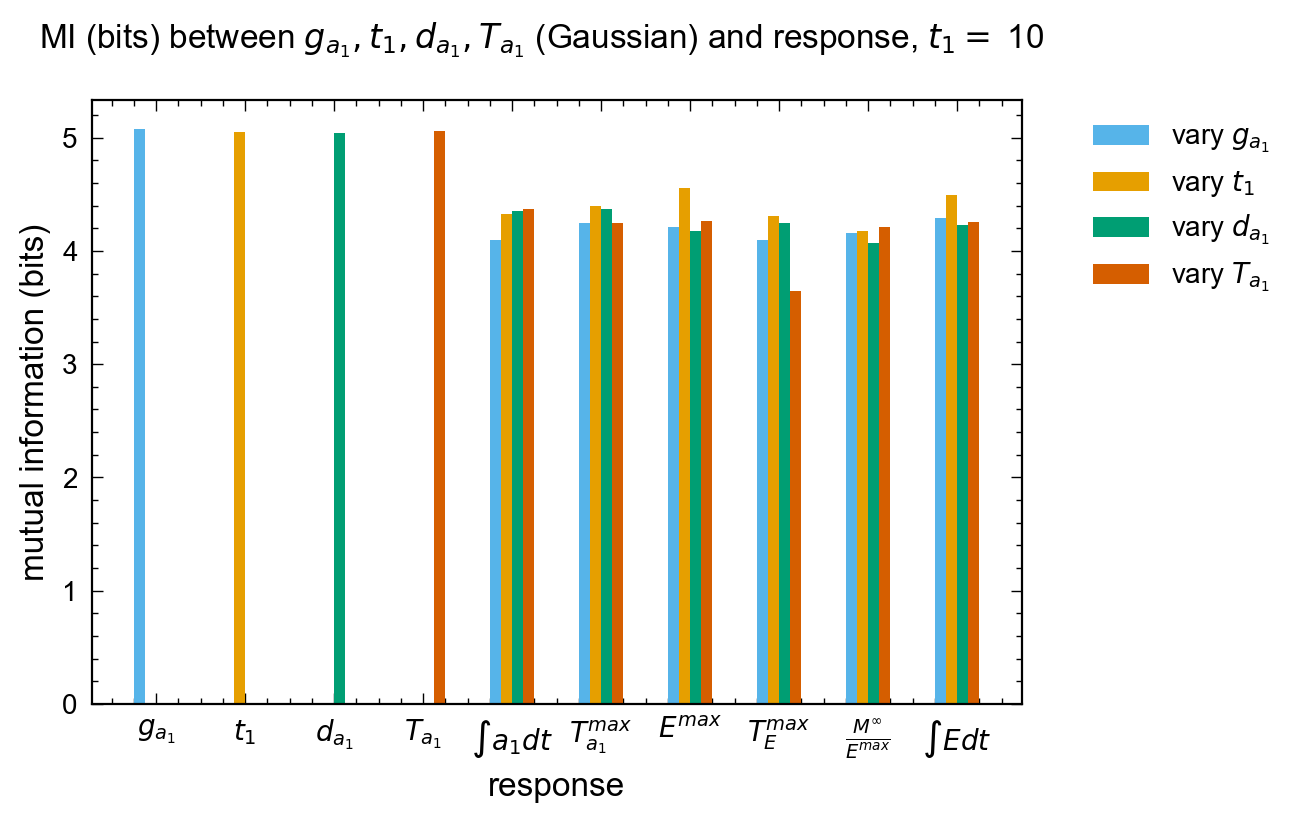

In [16]:
# Plot mutual information
plt.figure(1)

r = 2*np.arange(len(MI_b_a1))
width = 0.25
plt.bar(r, MI_b_a1, width = width, label = r'vary $g_{a_1}$')
plt.bar(r + width, MI_t1, width = width, label = r'vary $t_1$')
plt.bar(r + 2*width, MI_d_a1, width = width, label = r'vary $d_{a_1}$')
plt.bar(r + 3*width, MI_T_a1, width = width, label = r'vary $T_{a_1}$')

plt.xlabel("response")
plt.ylabel("mutual information (bits)")

plt.xticks(r + 3*width/2,stat_names)
#plt.legend()
plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
plt.suptitle(r'MI (bits) between $g_{a_1}, t_1, d_{a_1}, T_{a_1}$ (Gaussian) and response, $t_1=$ '+str(mu_t1))
plt.savefig('response-mutual-info-gauss-t1-'+str(mu_t1)+'.png', dpi=150)

## (6) Plot trajectories from simulations

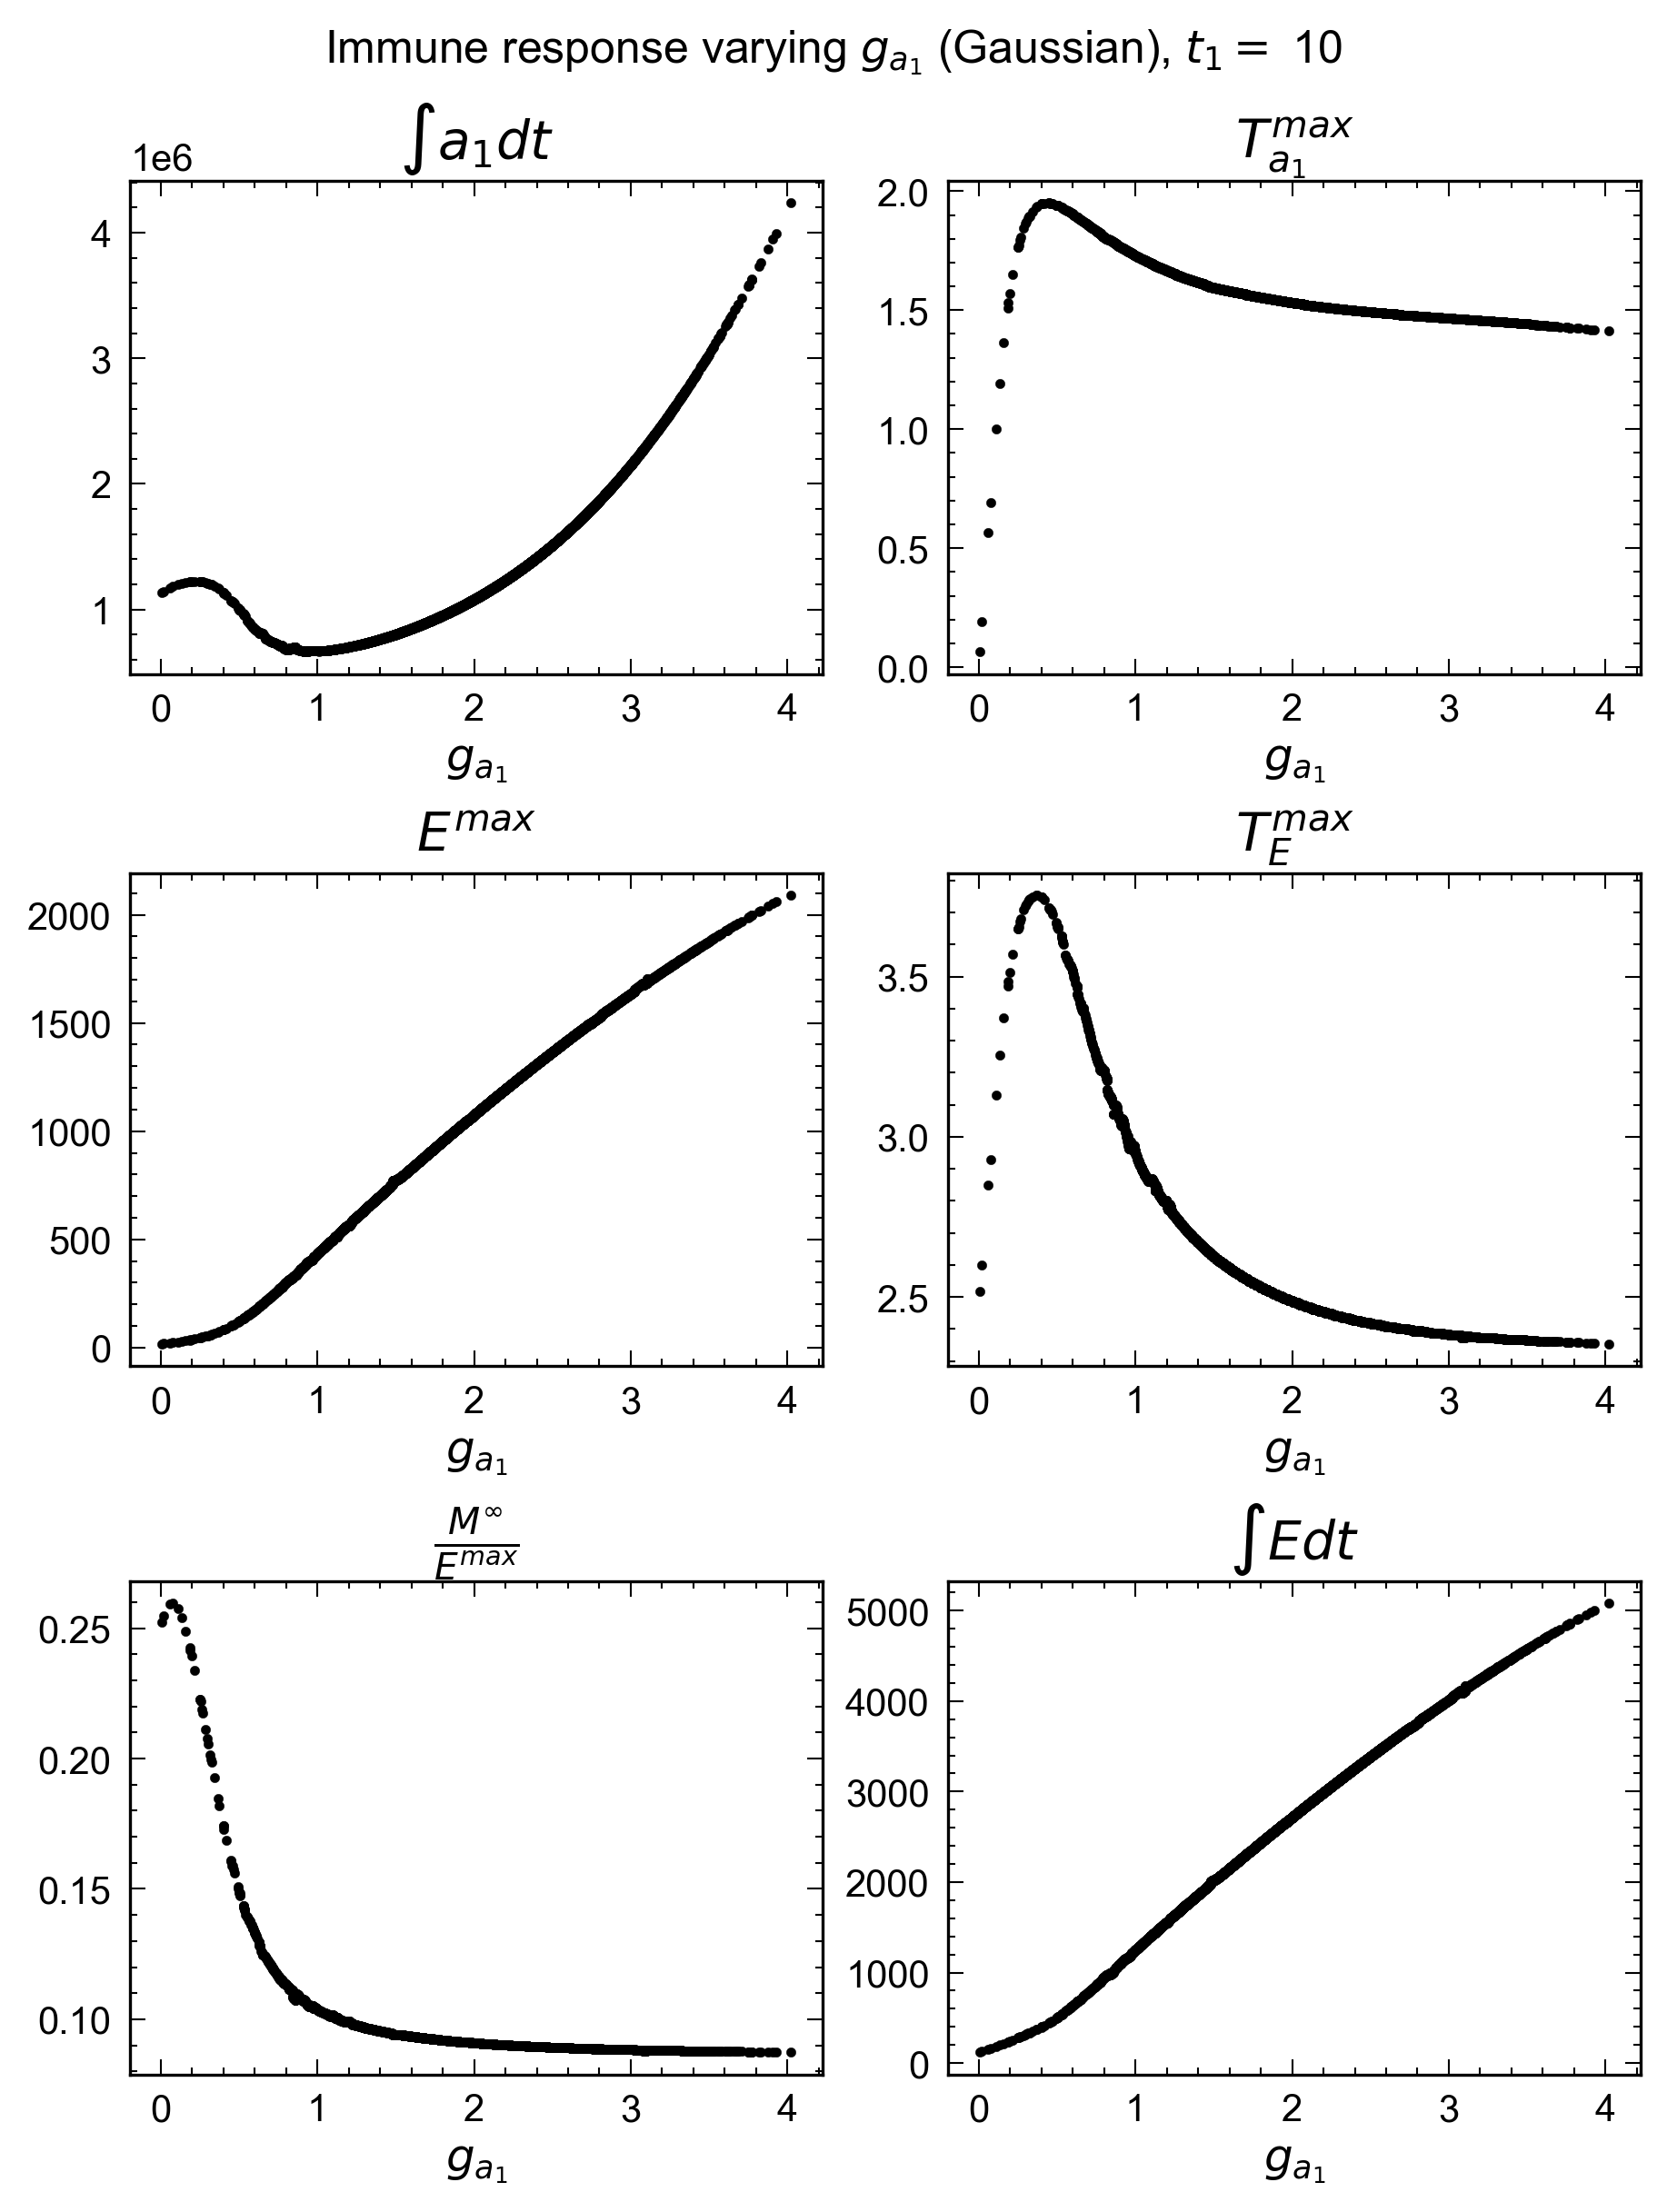

In [17]:
# Plot trajectories for b_a1
fig_b_a1, axs = plt.subplots(3, 2, dpi = 150, constrained_layout=True, figsize=(6,8))
i = 4
for ax, val in zip(axs.flat,stat_names[i:]):

    cs = ax.plot(run_data_b_a1[:,0],run_data_b_a1[:,i],'k.')
    ax.set_title(val)
    ax.set(xlabel=r'$g_{a_1}$')
        
    i += 1

fig_b_a1.suptitle(r'Immune response varying $g_{a_1}$ (Gaussian), $t_1=$ '+str(mu_t1))
plt.show()
fig_b_a1.savefig('plot-response-varying-b_a1-gauss-t1-'+str(mu_t1)+'.png', dpi=150)

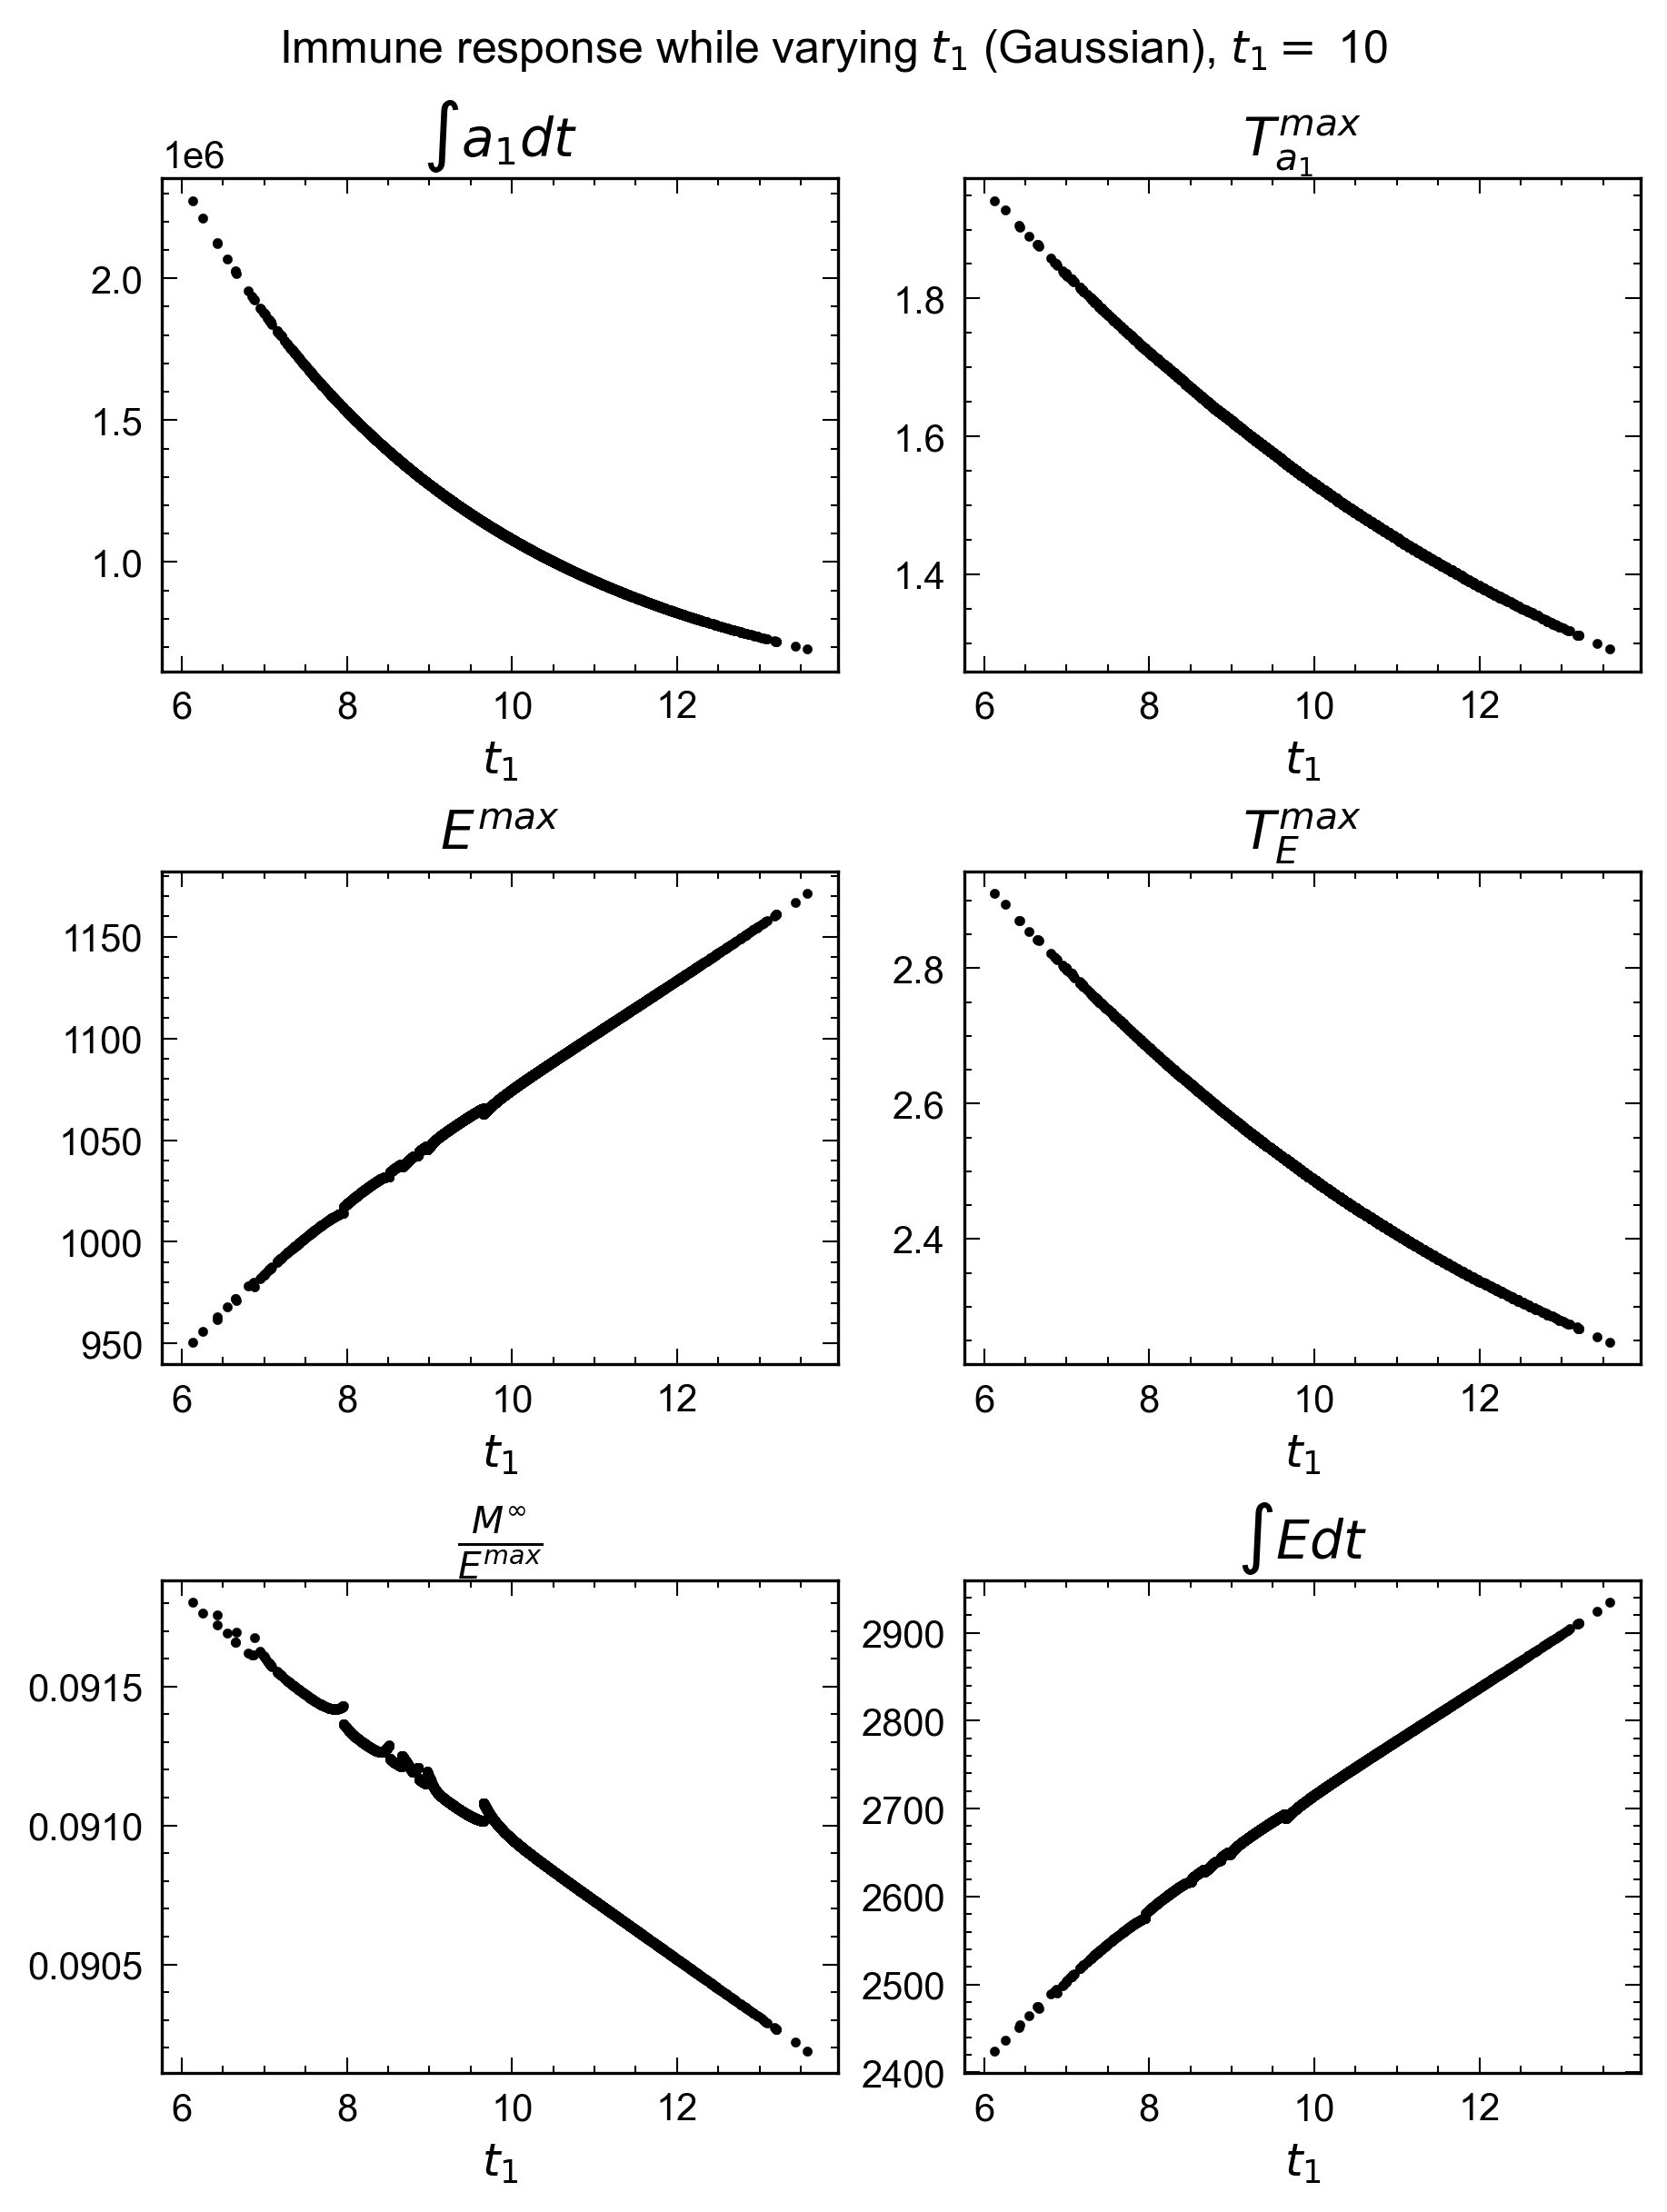

In [18]:
# Plot trajectories for t1
fig_t1, axs = plt.subplots(3, 2, dpi = 150, constrained_layout=True, figsize=(6,8))
i = 4
for ax, val in zip(axs.flat,stat_names[i:]):

    cs = ax.plot(run_data_t1[:,1],run_data_t1[:,i],'k.')
    ax.set_title(val)
    ax.set(xlabel=r'$t_1$')
        
    i += 1

fig_t1.suptitle(r'Immune response while varying $t_1$ (Gaussian), $t_1=$ '+str(mu_t1))
plt.show()
fig_t1.savefig('plot-response-varying-t1-gauss-t1-'+str(mu_t1)+'.png', dpi=150)

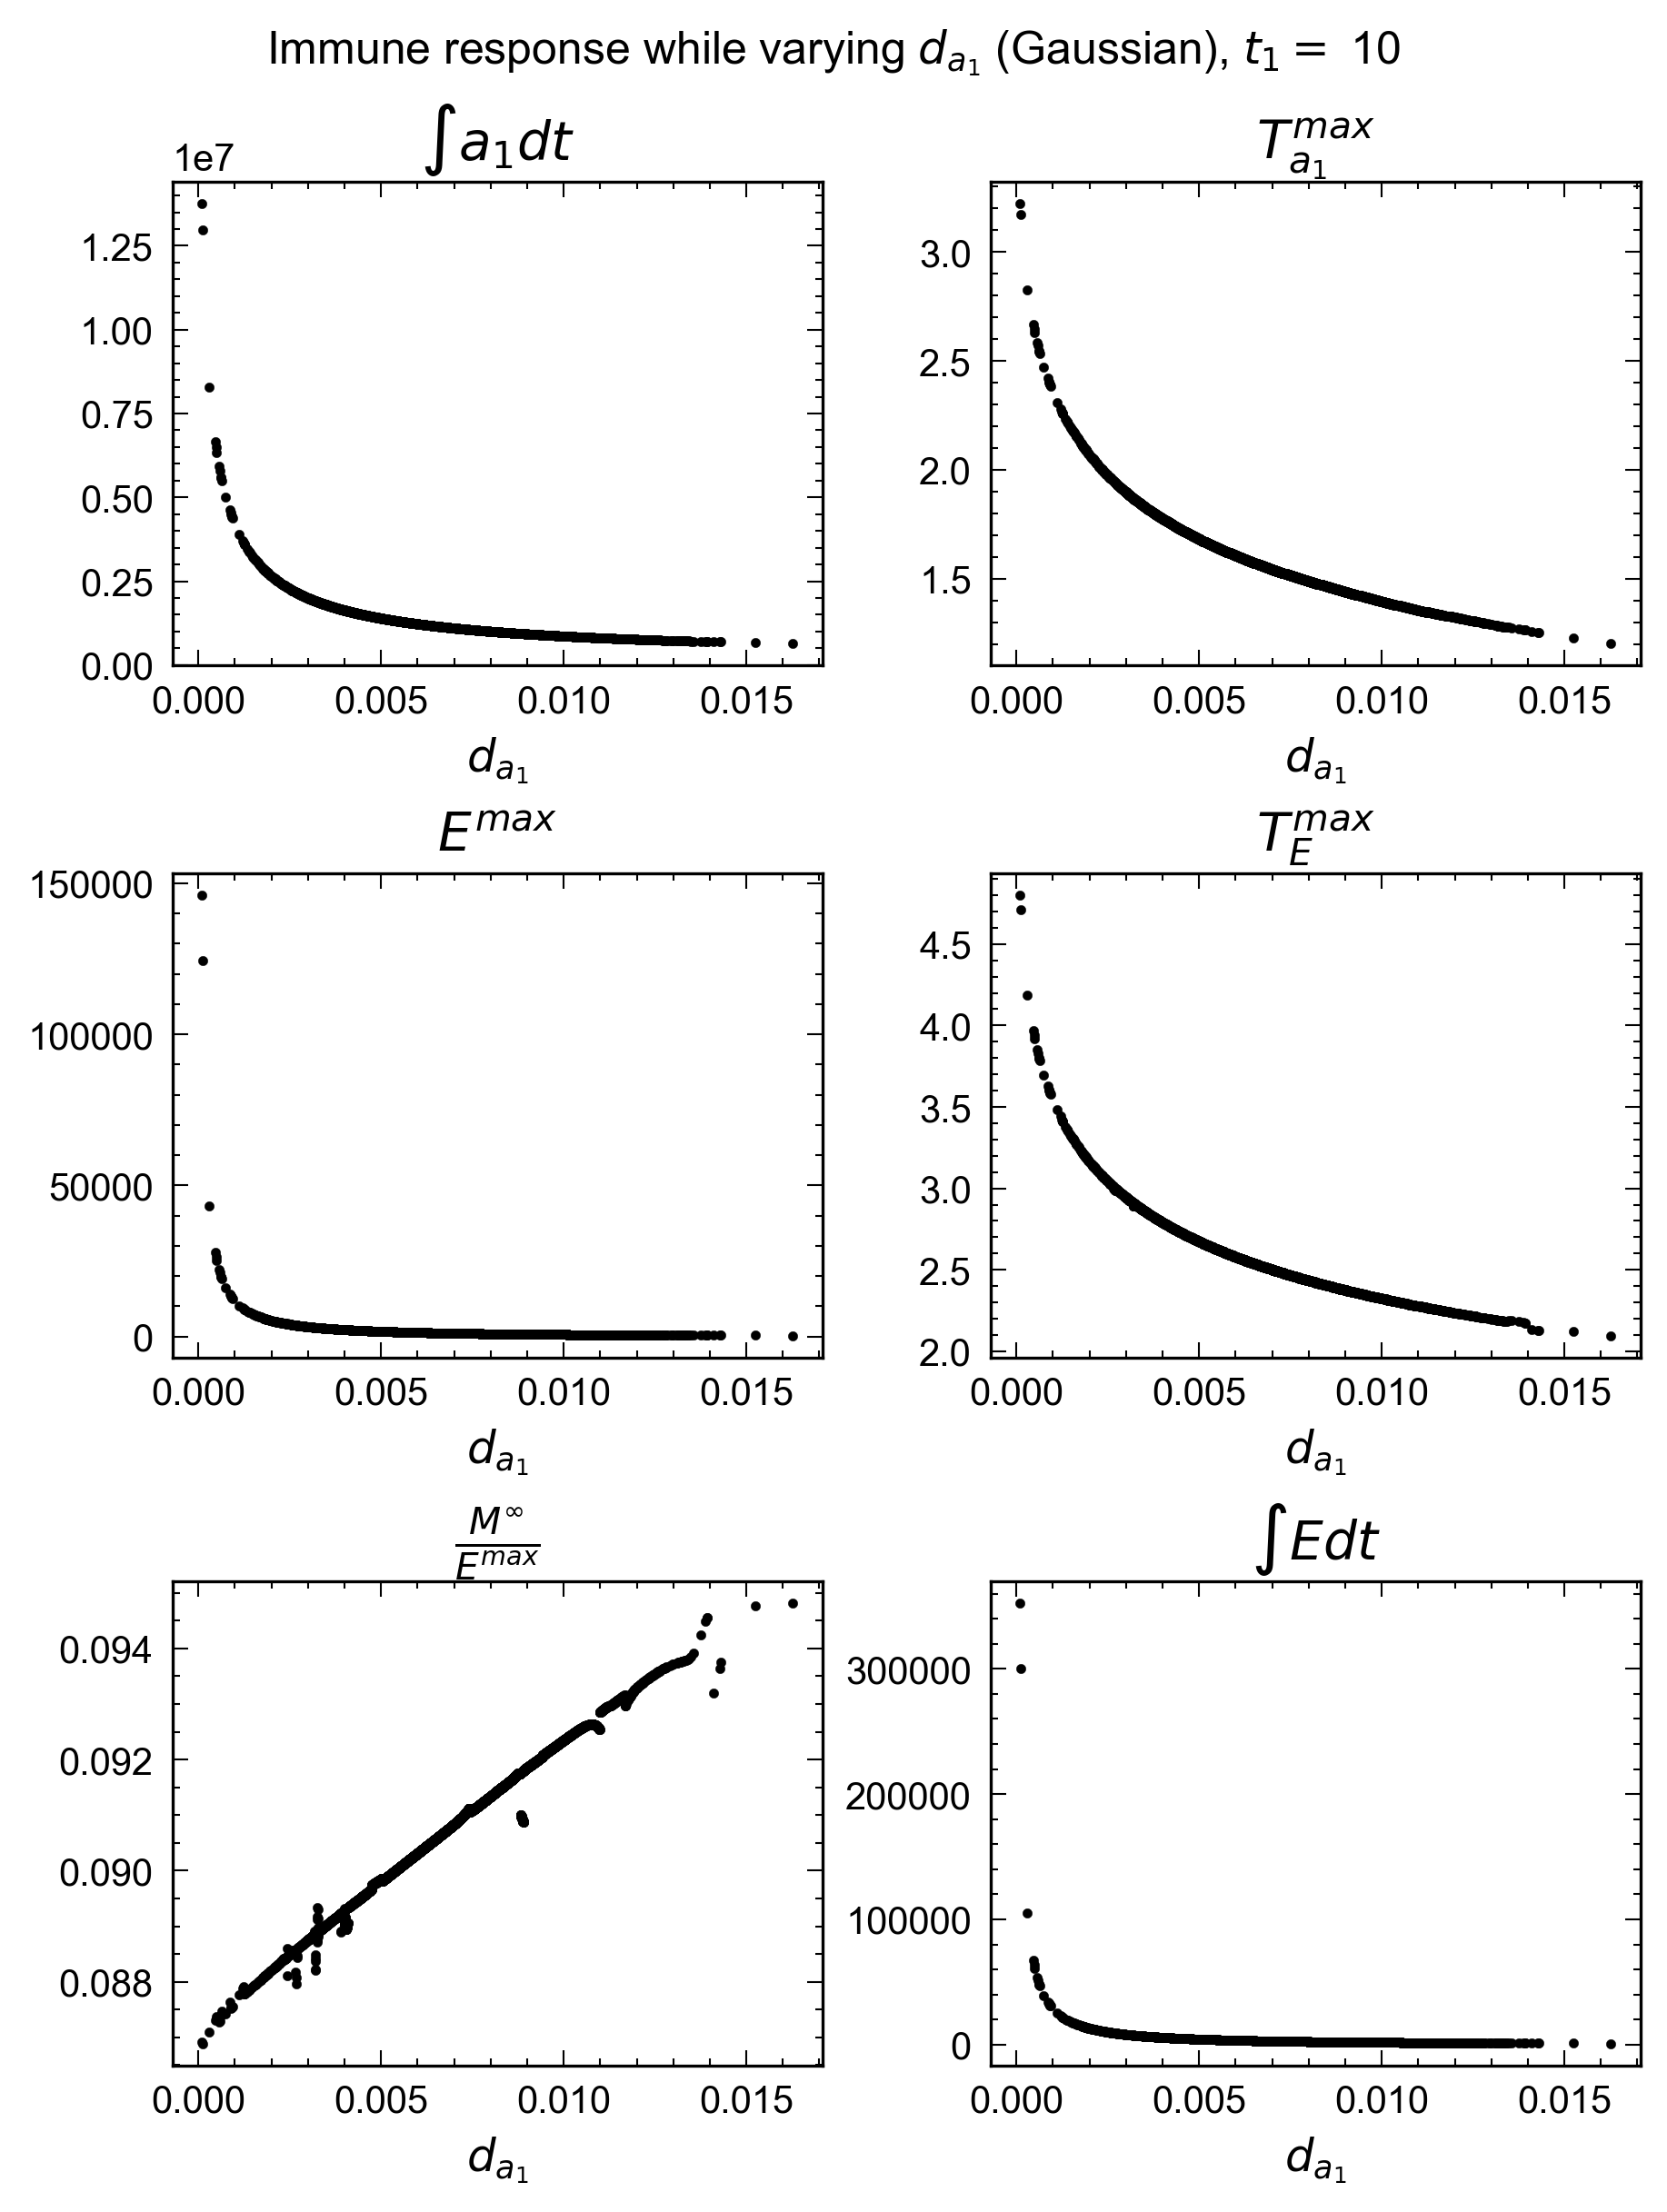

In [19]:
# Plot trajectories for d_a1
fig_t1, axs = plt.subplots(3, 2, dpi = 150, constrained_layout=True, figsize=(6,8))
i = 4
for ax, val in zip(axs.flat,stat_names[i:]):

    cs = ax.plot(run_data_d_a1[:,2],run_data_d_a1[:,i],'k.')
    ax.set_title(val)
    ax.set(xlabel=r'$d_{a_1}$')
        
    i += 1

fig_t1.suptitle(r'Immune response while varying $d_{a_1}$ (Gaussian), $t_1=$ '+str(mu_t1))
plt.show()
fig_t1.savefig('plot-response-varying-d_a1-gauss-t1-'+str(mu_t1)+'.png', dpi=150)

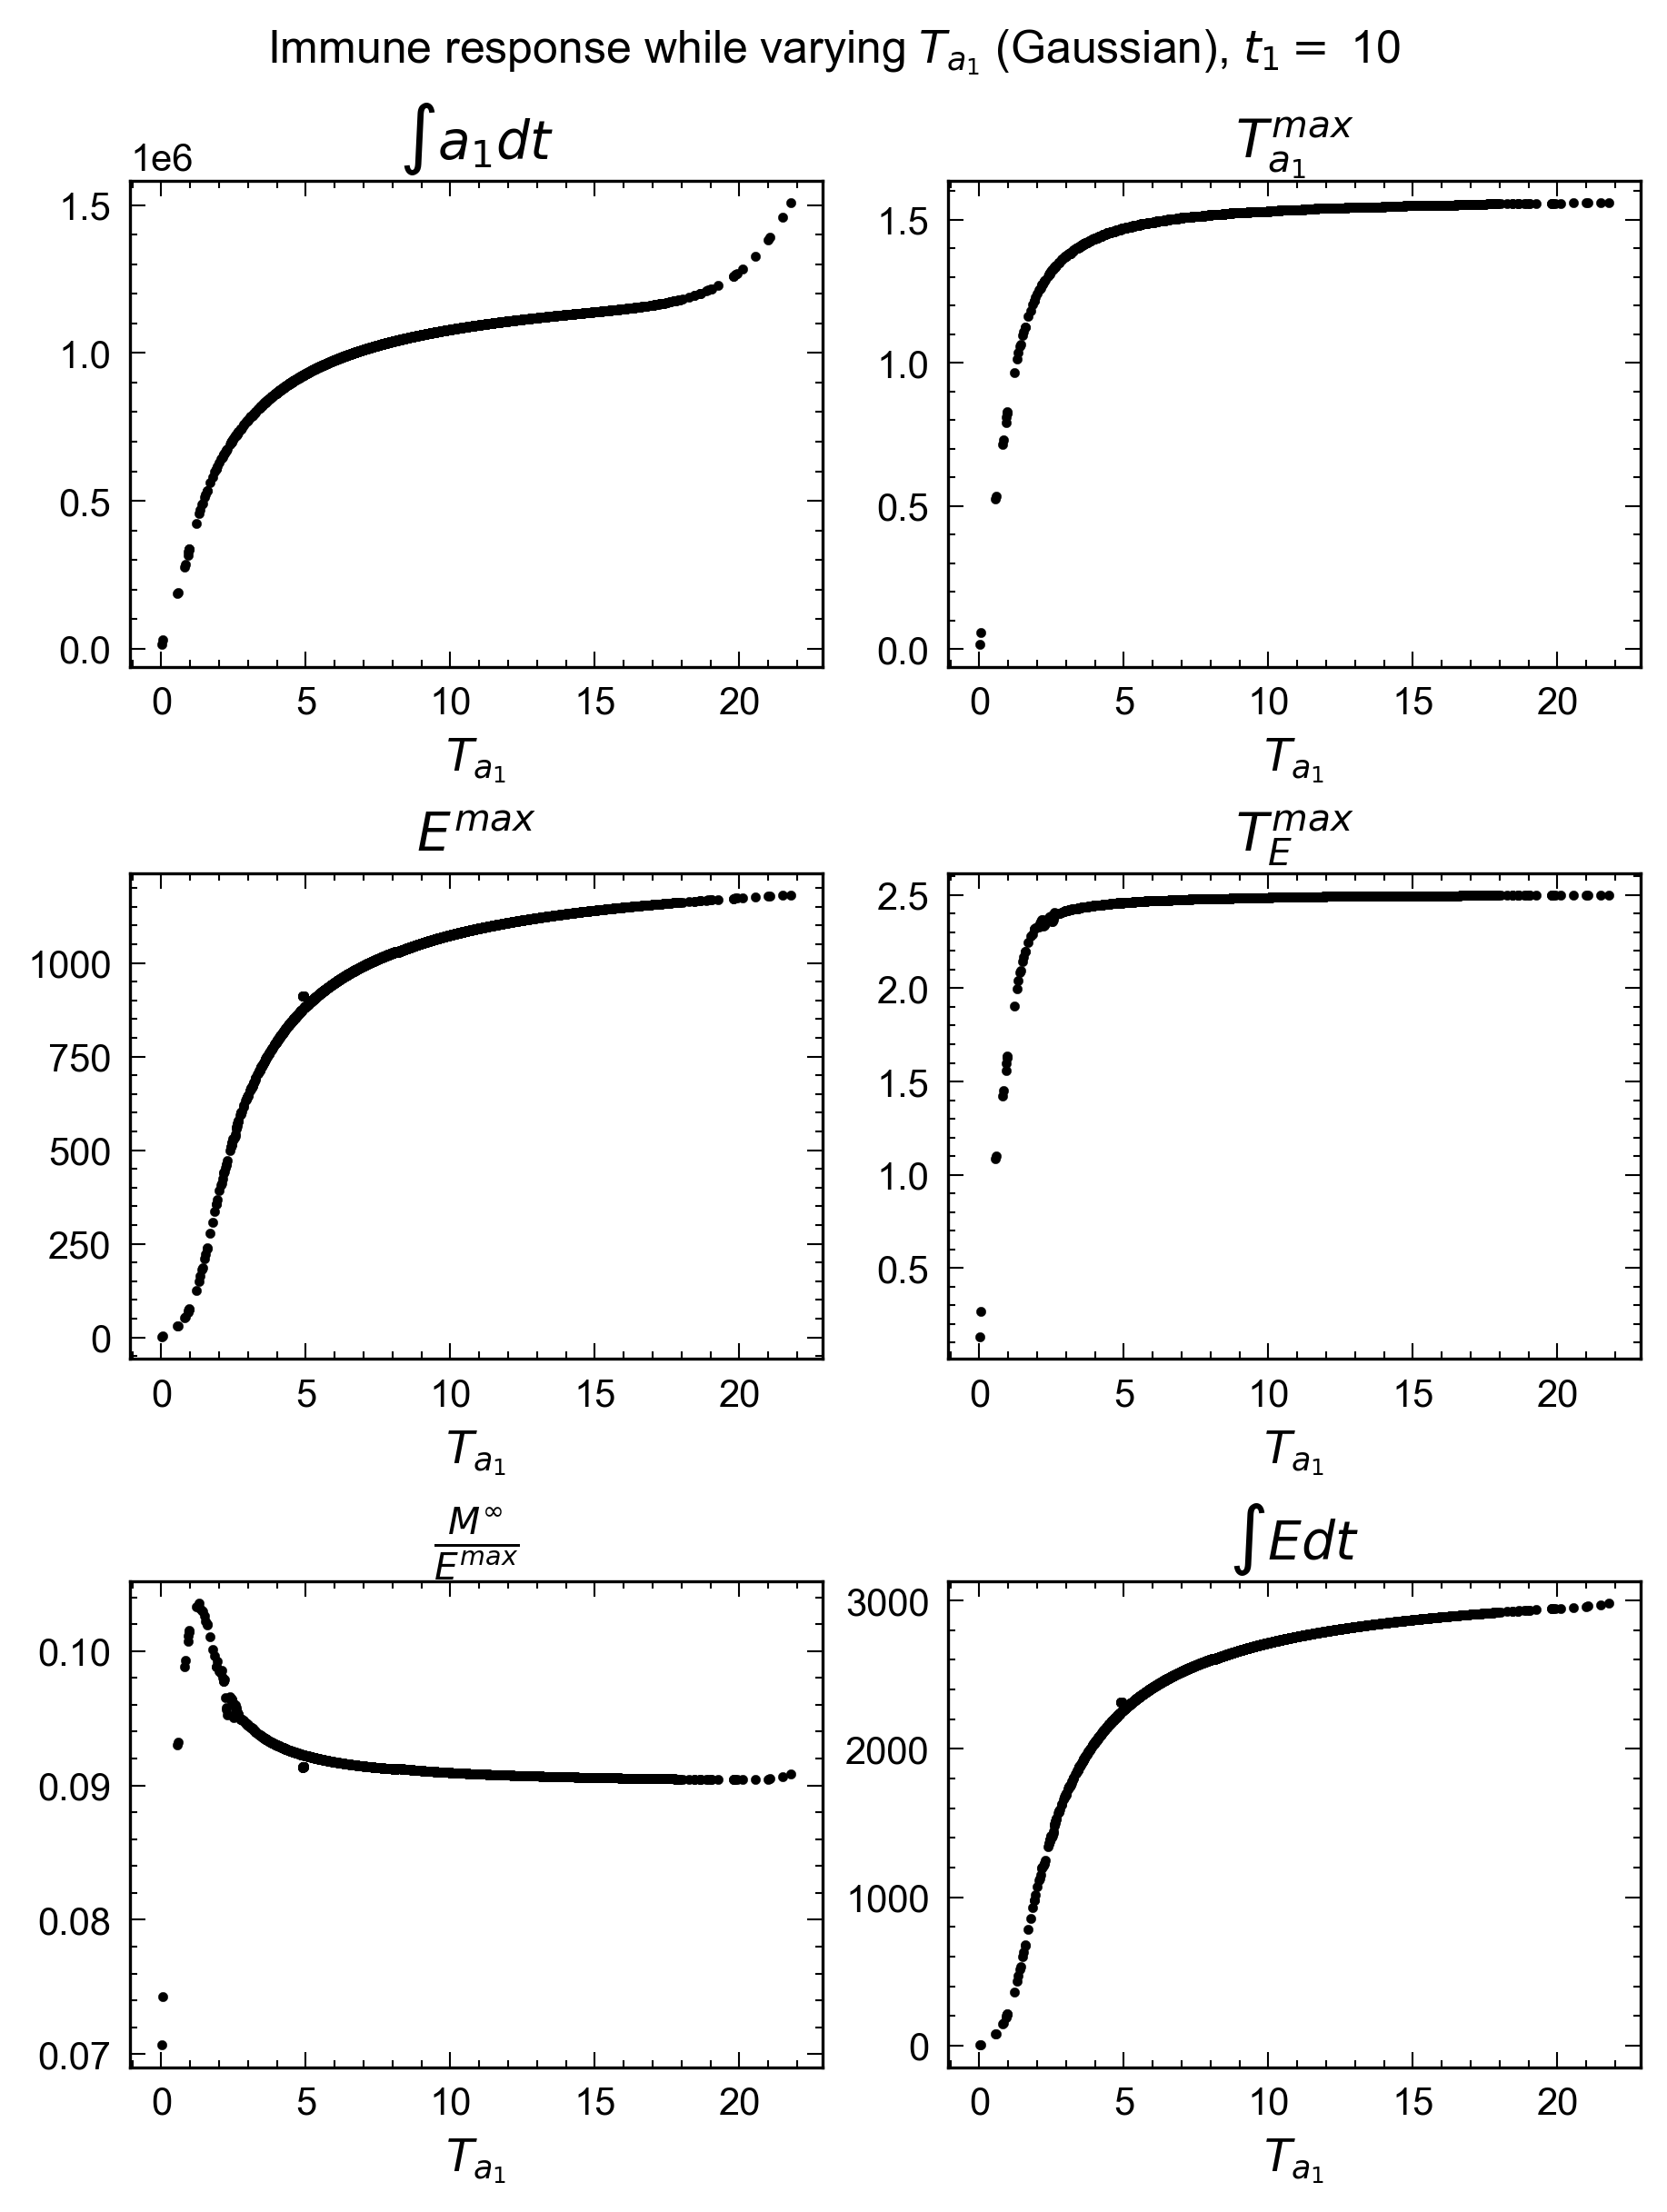

In [20]:
# Plot trajectories for T_a1
fig_t1, axs = plt.subplots(3, 2, dpi = 150, constrained_layout=True, figsize=(6,8))
i = 4
for ax, val in zip(axs.flat,stat_names[i:]):

    cs = ax.plot(run_data_T_a1[:,3],run_data_T_a1[:,i],'k.')
    ax.set_title(val)
    ax.set(xlabel=r'$T_{a_1}$')
        
    i += 1

fig_t1.suptitle(r'Immune response while varying $T_{a_1}$ (Gaussian), $t_1=$ '+str(mu_t1))
plt.show()
fig_t1.savefig('plot-response-varying-T_a1-gauss-t1-'+str(mu_t1)+'.png', dpi=150)